In [1]:
import sys, os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import efficient_su2

from src.runners import (
    run_vqe_trace_shots,
    build_combined_noise_model,
    build_depolarizing_noise_model,
    build_readout_noise_model,
    build_thermal_relaxation_noise_model,
)

from src.transformations import (
    vqe_identity,
    vqe_barrier,
    vqe_identity_xx,
    vqe_fault_x,
    vqe_fault_replace_rotation,
    vqe_fault_replace_rotation_strong,
    vqe_fault_shift_parameter,
    vqe_fault_shift_parameter_strong,
    vqe_fault_change_entanglement,
)

from src.checker import evaluate_vqe_pair, evaluate_vqe_pair_noisy, evaluate_vqe_pair_energy_only

In [2]:
import importlib
import src.checker as checker
importlib.reload(checker)

from src.checker import (
    compare_vqe_traces,
    evaluate_vqe_pair,
    evaluate_vqe_pair_shot_based,
    evaluate_vqe_pair_noisy,
)

In [3]:
sns.set_style("whitegrid")
plt.rcParams.update({"font.size": 12})

project_root = Path.cwd().parent
results_dir = project_root / "results"
figures_dir = results_dir / "figures"

results_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

print("Noisy Shot-Based VQE Metamorphic Testing Notebook")
print("=" * 60)
print(f"Project root: {project_root}")
print(f"Results dir: {results_dir}")
print(f"Figures dir: {figures_dir}")

Noisy Shot-Based VQE Metamorphic Testing Notebook
Project root: C:\Users\shask\Desktop\Winter 2026\CSI 5370\Project paper\metamorphic_quantum_testing
Results dir: C:\Users\shask\Desktop\Winter 2026\CSI 5370\Project paper\metamorphic_quantum_testing\results
Figures dir: C:\Users\shask\Desktop\Winter 2026\CSI 5370\Project paper\metamorphic_quantum_testing\results\figures


In [4]:
# PHASE 3: NOISY SHOT-BASED VQE METAMORPHIC TESTING

PHASE = "noisy_shot_based"

NUM_QUBITS = 4
REPS = 5
SHOTS = 2048
MAXITER = 60
NUM_RUNS = 10

# Tuned noisy-phase oracle
ENERGY_THRESHOLD = 0.10
SYMMETRY_THRESHOLD = 0.05
PARAM_THRESHOLD = float("inf")   # diagnostic only

RANDOM_SEED = 42

# Noise settings
NOISE_MODEL_NAME = "depolarizing_readout"

ONE_QUBIT_ERROR_RATE = 0.001
TWO_QUBIT_ERROR_RATE = 0.01
READOUT_ERROR_RATE = 0.02

INCLUDE_THERMAL = False
T1 = 50_000
T2 = 70_000
ONE_QUBIT_GATE_TIME = 50
TWO_QUBIT_GATE_TIME = 300

In [5]:
from qiskit.quantum_info import SparsePauliOp
import numpy as np

H = SparsePauliOp(
    ["ZZII", "IIZZ", "XXII", "IIXX"],
    coeffs=[-1.0, -1.0, 0.5, 0.5]
)

symmetry_op = SparsePauliOp(
    ["ZZII", "IIZZ"],
    coeffs=[1.0, 1.0]
)

def check_commutation(A, B, label_A="A", label_B="B"):
    comm = (A @ B - B @ A).simplify(atol=1e-12)

    print(f"\nCommutator [{label_A}, {label_B}]:")
    print(comm)

    if len(comm.paulis) == 0 or np.allclose(comm.coeffs, 0.0):
        print("Result: operators commute.\n")
        return True
    else:
        print("Result: operators do NOT commute.\n")
        return False

commutes = check_commutation(H, symmetry_op, "H", "symmetry_op")


Commutator [H, symmetry_op]:
SparsePauliOp(['IIII'],
              coeffs=[0.+0.j])
Result: operators commute.



In [6]:
from qiskit.circuit.library import efficient_su2

ansatz = efficient_su2(
    NUM_QUBITS,
    reps=REPS,
    entanglement="full",
)

print("Original ansatz:")
print(f"Number of qubits: {ansatz.num_qubits}")
print(f"Number of parameters: {ansatz.num_parameters}")
print(f"Circuit depth: {ansatz.depth()}")

relations = {
    "identity": {
        "transform": vqe_identity,
        "type": "valid",
    },
    "barrier": {
        "transform": vqe_barrier,
        "type": "valid",
    },
    "identity_xx": {
        "transform": vqe_identity_xx,
        "type": "valid",
    },
    "fault_x": {
        "transform": vqe_fault_x,
        "type": "fault",
    },
    "fault_replace_rot": {
        "transform": vqe_fault_replace_rotation,
        "type": "fault",
    },
    "fault_replace_rot_strong": {
        "transform": vqe_fault_replace_rotation_strong,
        "type": "fault",
    },
    "fault_shift_param": {
        "transform": vqe_fault_shift_parameter,
        "type": "fault",
    },
    "fault_shift_param_strong": {
        "transform": vqe_fault_shift_parameter_strong,
        "type": "fault",
    },
    "fault_change_entanglement": {
        "transform": vqe_fault_change_entanglement,
        "type": "fault",
    },
}

def apply_transform(transform, ansatz, seed):
    try:
        return transform(ansatz, seed=seed)
    except TypeError:
        return transform(ansatz)

Original ansatz:
Number of qubits: 4
Number of parameters: 48
Circuit depth: 33


In [7]:
noise_model = build_combined_noise_model(
    one_qubit_error_rate=ONE_QUBIT_ERROR_RATE,
    two_qubit_error_rate=TWO_QUBIT_ERROR_RATE,
    readout_error_rate=READOUT_ERROR_RATE,
    include_thermal=INCLUDE_THERMAL,
    t1=T1,
    t2=T2,
    one_qubit_gate_time=ONE_QUBIT_GATE_TIME,
    two_qubit_gate_time=TWO_QUBIT_GATE_TIME,
)

print(f"Using noise model: {NOISE_MODEL_NAME}")

Using noise model: depolarizing_readout


In [9]:
rng = np.random.default_rng(RANDOM_SEED)

initial_points = [
    rng.uniform(-0.1, 0.1, ansatz.num_parameters)
    for _ in range(NUM_RUNS)
]

In [10]:
results_noisy = []
run_level_results_noisy = []

print(
    f"\nRunning {PHASE} VQE metamorphic testing "
    f"({NUM_RUNS} paired runs per relation, {SHOTS} shots)...\n"
)

for relation_name, relation_info in relations.items():
    transform = relation_info["transform"]
    relation_type = relation_info["type"]

    print(f"→ Testing: {relation_name}")

    delta_E_list = []
    avg_energy_diff_list = []
    max_energy_diff_list = []

    avg_sym_diff_list = []
    max_sym_diff_list = []

    avg_param_diff_list = []
    max_param_diff_list = []

    detected_list = []

    for run in range(NUM_RUNS):
        initial_point = initial_points[run]

        # Shared seed for source/follow-up pair
        pair_seed = 300_000 + run
        transform_seed = 2_000 + run

        follow_ansatz = apply_transform(
            transform=transform,
            ansatz=ansatz,
            seed=transform_seed,
        )

        if follow_ansatz.num_parameters == ansatz.num_parameters:
            follow_initial_point = initial_point
        else:
            follow_initial_point = rng.uniform(
                -0.1, 0.1, follow_ansatz.num_parameters
            )

        source_result, source_trace = run_vqe_trace_shots(
            ansatz=ansatz,
            hamiltonian=H,
            symmetry_op=symmetry_op,
            initial_point=initial_point,
            shots=SHOTS,
            maxiter=MAXITER,
            seed=pair_seed,
            noise_model=noise_model,
        )

        follow_result, follow_trace = run_vqe_trace_shots(
            ansatz=follow_ansatz,
            hamiltonian=H,
            symmetry_op=symmetry_op,
            initial_point=follow_initial_point,
            shots=SHOTS,
            maxiter=MAXITER,
            seed=pair_seed,
            noise_model=noise_model,
        )

        metrics = evaluate_vqe_pair_noisy(
            source_result=source_result,
            follow_result=follow_result,
            source_trace=source_trace,
            follow_trace=follow_trace,
            energy_threshold=ENERGY_THRESHOLD,
            symmetry_threshold=SYMMETRY_THRESHOLD,
        )

        delta_E_list.append(metrics["delta_E"])
        avg_energy_diff_list.append(metrics["avg_energy_diff"])
        max_energy_diff_list.append(metrics["max_energy_diff"])

        avg_sym_diff_list.append(metrics["avg_sym_diff"])
        max_sym_diff_list.append(metrics["max_sym_diff"])

        avg_param_diff_list.append(metrics["avg_param_diff"])
        max_param_diff_list.append(metrics["max_param_diff"])

        detected_list.append(metrics["violation"])

        run_level_results_noisy.append({
            "phase": PHASE,
            "relation": relation_name,
            "type": relation_type,
            "run": run + 1,

            "num_qubits": NUM_QUBITS,
            "reps": REPS,
            "maxiter": MAXITER,
            "shots": SHOTS,

            "optimizer": "SPSA",
            "oracle_variant": "deltaE_or_avgSym",
            "noise_model": NOISE_MODEL_NAME,

            "one_qubit_error_rate": ONE_QUBIT_ERROR_RATE,
            "two_qubit_error_rate": TWO_QUBIT_ERROR_RATE,
            "readout_error_rate": READOUT_ERROR_RATE,
            "include_thermal": INCLUDE_THERMAL,

            "energy_threshold": ENERGY_THRESHOLD,
            "symmetry_threshold": SYMMETRY_THRESHOLD,
            "param_threshold": PARAM_THRESHOLD,

            "random_seed": RANDOM_SEED,
            "pair_seed": pair_seed,
            "transform_seed": transform_seed,
            "hamiltonian_symmetry_commute": commutes,

            "source_num_parameters": ansatz.num_parameters,
            "follow_num_parameters": follow_ansatz.num_parameters,

            "source_depth": ansatz.depth(),
            "follow_depth": follow_ansatz.depth(),

            "delta_E": round(metrics["delta_E"], 8),

            "avg_energy_diff": round(metrics["avg_energy_diff"], 8),
            "max_energy_diff": round(metrics["max_energy_diff"], 8),

            "avg_sym_diff": round(metrics["avg_sym_diff"], 8),
            "max_sym_diff": round(metrics["max_sym_diff"], 8),

            "avg_param_diff": round(metrics["avg_param_diff"], 8),
            "max_param_diff": round(metrics["max_param_diff"], 8),

            "trace_len": int(metrics["trace_len"]),

            "energy_violation": bool(metrics["energy_violation"]),
            "symmetry_violation": bool(metrics["symmetry_violation"]),
            "violation": bool(metrics["violation"]),
        })

    results_noisy.append({
        "phase": PHASE,
        "relation": relation_name,
        "type": relation_type,

        "num_qubits": NUM_QUBITS,
        "reps": REPS,
        "maxiter": MAXITER,
        "shots": SHOTS,

        "optimizer": "SPSA",
        "oracle_variant": "deltaE_or_avgSym",
        "noise_model": NOISE_MODEL_NAME,

        "one_qubit_error_rate": ONE_QUBIT_ERROR_RATE,
        "two_qubit_error_rate": TWO_QUBIT_ERROR_RATE,
        "readout_error_rate": READOUT_ERROR_RATE,
        "include_thermal": INCLUDE_THERMAL,

        "energy_threshold": ENERGY_THRESHOLD,
        "symmetry_threshold": SYMMETRY_THRESHOLD,
        "param_threshold": PARAM_THRESHOLD,

        "mean_delta_E": round(np.mean(delta_E_list), 6),
        "std_delta_E": round(np.std(delta_E_list), 6),

        "mean_avg_energy_diff": round(np.mean(avg_energy_diff_list), 6),
        "mean_max_energy_diff": round(np.mean(max_energy_diff_list), 6),

        "mean_sym_diff": round(np.mean(avg_sym_diff_list), 6),
        "mean_max_sym_diff": round(np.mean(max_sym_diff_list), 6),

        "mean_param_diff": round(np.mean(avg_param_diff_list), 6),
        "mean_max_param_diff": round(np.mean(max_param_diff_list), 6),

        "detection_rate": round(np.mean(detected_list) * 100, 2),
    })


Running noisy_shot_based VQE metamorphic testing (10 paired runs per relation, 2048 shots)...

→ Testing: identity
→ Testing: barrier
→ Testing: identity_xx
→ Testing: fault_x
→ Testing: fault_replace_rot
→ Testing: fault_replace_rot_strong
→ Testing: fault_shift_param
→ Testing: fault_shift_param_strong
→ Testing: fault_change_entanglement


In [11]:
df_vqe_noisy = pd.DataFrame(results_noisy)
df_vqe_noisy_runs = pd.DataFrame(run_level_results_noisy)

df_vqe_noisy.to_csv(
    results_dir / "vqe_results_4q_noisy_shot_based.csv",
    index=False,
)

df_vqe_noisy_runs.to_csv(
    results_dir / "vqe_run_level_results_4q_noisy_shot_based.csv",
    index=False,
)

print("\nNoisy shot-based VQE experiment completed.")
print(f"Summary saved to: {results_dir / 'vqe_results_4q_noisy_shot_based.csv'}")
print(f"Run-level saved to: {results_dir / 'vqe_run_level_results_4q_noisy_shot_based.csv'}")

display(df_vqe_noisy)
display(df_vqe_noisy_runs.head())


Noisy shot-based VQE experiment completed.
Summary saved to: C:\Users\shask\Desktop\Winter 2026\CSI 5370\Project paper\metamorphic_quantum_testing\results\vqe_results_4q_noisy_shot_based.csv
Run-level saved to: C:\Users\shask\Desktop\Winter 2026\CSI 5370\Project paper\metamorphic_quantum_testing\results\vqe_run_level_results_4q_noisy_shot_based.csv


,phase,relation,type,num_qubits,reps,maxiter,shots,optimizer,oracle_variant,noise_model,...,param_threshold,mean_delta_E,std_delta_E,mean_avg_energy_diff,mean_max_energy_diff,mean_sym_diff,mean_max_sym_diff,mean_param_diff,mean_max_param_diff,detection_rate
0,noisy_shot_based,identity,valid,4,5,60,2048,SPSA,deltaE_or_avgSym,depolarizing_readout,...,inf,0.019678,0.018804,0.018343,0.109912,0.014443,0.088379,0.210007,0.481047,0.0
1,noisy_shot_based,barrier,valid,4,5,60,2048,SPSA,deltaE_or_avgSym,depolarizing_readout,...,inf,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
2,noisy_shot_based,identity_xx,valid,4,5,60,2048,SPSA,deltaE_or_avgSym,depolarizing_readout,...,inf,0.011328,0.013436,0.011585,0.075195,0.009217,0.062402,0.120836,0.313377,0.0
3,noisy_shot_based,fault_x,fault,4,5,60,2048,SPSA,deltaE_or_avgSym,depolarizing_readout,...,inf,0.463232,0.478660,0.673447,1.329883,0.619696,1.205664,1.495580,2.493002,100.0
4,noisy_shot_based,fault_replace_rot,fault,4,5,60,2048,SPSA,deltaE_or_avgSym,depolarizing_readout,...,inf,0.058643,0.045958,0.057104,0.277490,0.035147,0.234473,0.672232,1.244839,10.0
5,noisy_shot_based,fault_replace_rot_strong,fault,4,5,60,2048,SPSA,deltaE_or_avgSym,depolarizing_readout,...,inf,0.478076,0.335051,0.540321,1.306592,0.393606,1.081250,1.995886,2.865961,100.0
6,noisy_shot_based,fault_shift_param,fault,4,5,60,2048,SPSA,deltaE_or_avgSym,depolarizing_readout,...,inf,0.120752,0.093851,0.148337,0.435303,0.064178,0.294434,0.812964,1.436153,70.0
7,noisy_shot_based,fault_shift_param_strong,fault,4,5,60,2048,SPSA,deltaE_or_avgSym,depolarizing_readout,...,inf,0.375342,0.284221,0.411256,0.923730,0.273887,0.765039,1.247628,2.119758,100.0
8,noisy_shot_based,fault_change_entanglement,fault,4,5,60,2048,SPSA,deltaE_or_avgSym,depolarizing_readout,...,inf,0.091309,0.077792,0.136799,0.511572,0.114122,0.405469,1.272922,2.289841,100.0


,phase,relation,type,run,num_qubits,reps,maxiter,shots,optimizer,oracle_variant,...,avg_energy_diff,max_energy_diff,avg_sym_diff,max_sym_diff,avg_param_diff,max_param_diff,trace_len,energy_violation,symmetry_violation,violation
0,noisy_shot_based,identity,valid,1,4,5,60,2048,SPSA,deltaE_or_avgSym,...,0.013923,0.091309,0.011301,0.070312,0.135122,0.356286,257,False,False,False
1,noisy_shot_based,identity,valid,2,4,5,60,2048,SPSA,deltaE_or_avgSym,...,0.018180,0.098145,0.011407,0.055664,0.101542,0.302275,257,False,False,False
2,noisy_shot_based,identity,valid,3,4,5,60,2048,SPSA,deltaE_or_avgSym,...,0.058941,0.333984,0.042551,0.241211,0.896761,1.583757,257,False,False,False
3,noisy_shot_based,identity,valid,4,4,5,60,2048,SPSA,deltaE_or_avgSym,...,0.010123,0.042480,0.006646,0.036133,0.077783,0.134614,257,False,False,False
4,noisy_shot_based,identity,valid,5,4,5,60,2048,SPSA,deltaE_or_avgSym,...,0.006975,0.032715,0.006015,0.021484,0.029591,0.088421,257,False,False,False


In [12]:
summary_eval = df_vqe_noisy.copy()

summary_eval["metric_name"] = summary_eval["type"].map({
    "valid": "false_positive_rate",
    "fault": "detection_rate"
})

display(summary_eval[[
    "relation",
    "type",
    "metric_name",
    "detection_rate",
    "mean_delta_E",
    "mean_sym_diff",
    "mean_param_diff"
]])

,relation,type,metric_name,detection_rate,mean_delta_E,mean_sym_diff,mean_param_diff
0,identity,valid,false_positive_rate,0.0,0.019678,0.014443,0.210007
1,barrier,valid,false_positive_rate,0.0,0.000000,0.000000,0.000000
2,identity_xx,valid,false_positive_rate,0.0,0.011328,0.009217,0.120836
3,fault_x,fault,detection_rate,100.0,0.463232,0.619696,1.495580
4,fault_replace_rot,fault,detection_rate,10.0,0.058643,0.035147,0.672232
5,fault_replace_rot_strong,fault,detection_rate,100.0,0.478076,0.393606,1.995886
6,fault_shift_param,fault,detection_rate,70.0,0.120752,0.064178,0.812964
7,fault_shift_param_strong,fault,detection_rate,100.0,0.375342,0.273887,1.247628
8,fault_change_entanglement,fault,detection_rate,100.0,0.091309,0.114122,1.272922


In [13]:
trigger_summary = (
    df_vqe_noisy_runs
    .groupby(["relation", "type"])[["energy_violation", "symmetry_violation", "violation"]]
    .mean()
    .round(3)
)

display(trigger_summary)

,,energy_violation,symmetry_violation,violation
relation,type,,,
barrier,valid,0.0,0.0,0.0
fault_change_entanglement,fault,0.4,1.0,1.0
fault_replace_rot,fault,0.1,0.0,0.1
fault_replace_rot_strong,fault,0.9,1.0,1.0
fault_shift_param,fault,0.5,0.4,0.7
fault_shift_param_strong,fault,0.8,0.9,1.0
fault_x,fault,0.7,1.0,1.0
identity,valid,0.0,0.0,0.0
identity_xx,valid,0.0,0.0,0.0


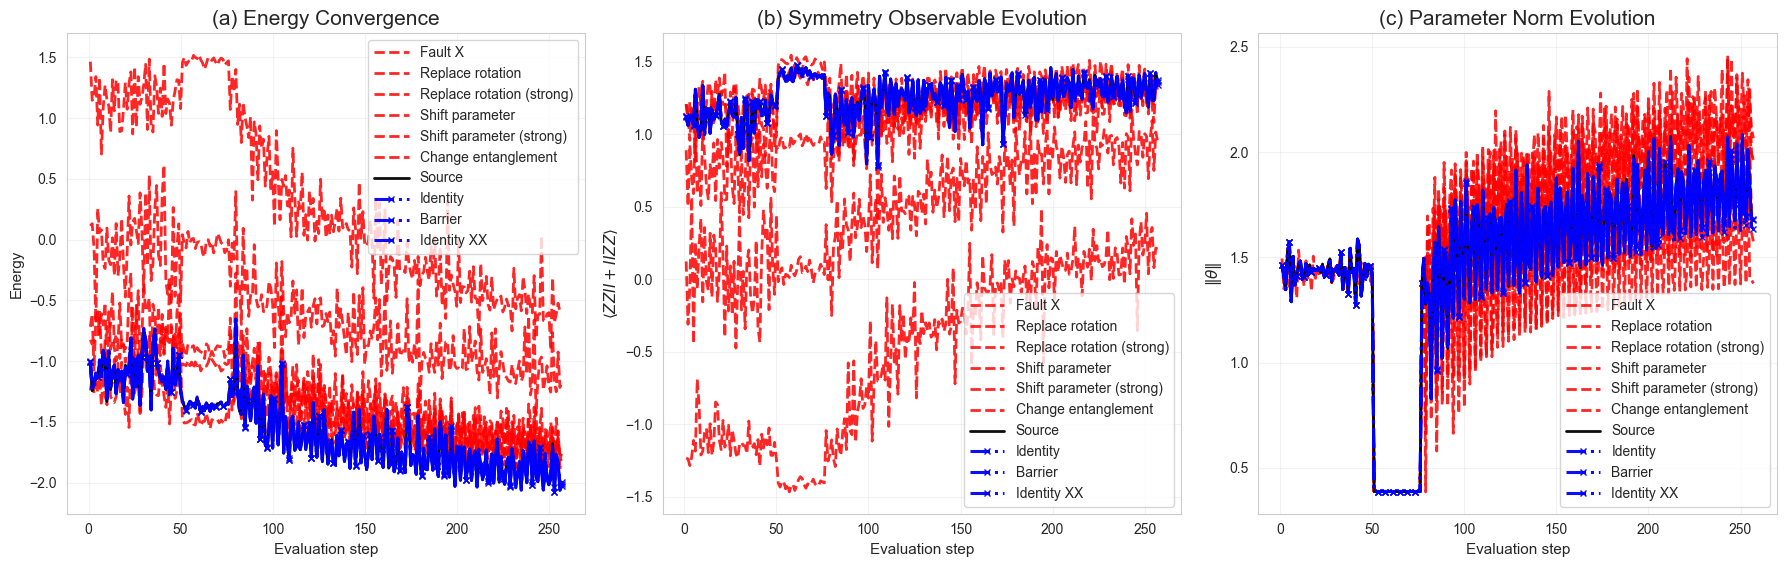

In [20]:
# NOISY SHOT-BASED VQE OPTIMIZATION PATHS

def pretty_relation_name(name: str) -> str:
    mapping = {
        "identity": "Identity",
        "barrier": "Barrier",
        "identity_xx": "Identity XX",
        "fault_x": "Fault X",
        "fault_replace_rot": "Replace rotation",
        "fault_replace_rot_strong": "Replace rotation (strong)",
        "fault_shift_param": "Shift parameter",
        "fault_shift_param_strong": "Shift parameter (strong)",
        "fault_change_entanglement": "Change entanglement",
    }
    return mapping.get(name, name)

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 16,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "lines.linewidth": 2.0,
})

# Use one representative initial point for the figure
initial_point = initial_points[0]

source_result, source_trace = run_vqe_trace_shots(
    ansatz=ansatz,
    hamiltonian=H,
    symmetry_op=symmetry_op,
    initial_point=initial_point,
    shots=SHOTS,
    maxiter=MAXITER,
    seed=100_000,
    noise_model=noise_model,
)

followup_traces = []

for idx, (name, relation_info) in enumerate(relations.items()):
    transform = relation_info["transform"]

    follow_ansatz = apply_transform(
        transform=transform,
        ansatz=ansatz,
        seed=1_000 + idx,
    )

    if follow_ansatz.num_parameters == ansatz.num_parameters:
        follow_initial_point = initial_point
    else:
        follow_initial_point = rng.uniform(
            -0.1,
            0.1,
            follow_ansatz.num_parameters,
        )

    _, follow_trace = run_vqe_trace_shots(
        ansatz=follow_ansatz,
        hamiltonian=H,
        symmetry_op=symmetry_op,
        initial_point=follow_initial_point,
        shots=SHOTS,
        maxiter=MAXITER,
        seed=100_000,
        noise_model=noise_model,
    )

    followup_traces.append((name, follow_trace))

valid_traces = [
    (name, tr)
    for name, tr in followup_traces
    if "fault" not in name
]

fault_traces = [
    (name, tr)
    for name, tr in followup_traces
    if "fault" in name
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.8), sharex=False)

# (a) ENERGY
for name, follow_trace in fault_traces:
    axes[0].plot(
        follow_trace["eval"],
        follow_trace["energy"],
        label=pretty_relation_name(name),
        linestyle="--",
        linewidth=2,
        color="red",
        alpha=0.85,
        zorder=2,
    )

axes[0].plot(
    source_trace["eval"],
    source_trace["energy"],
    label="Source",
    color="black",
    linewidth=2.0,
    alpha=0.95,
    zorder=3,
)

for name, follow_trace in valid_traces:
    axes[0].plot(
        follow_trace["eval"],
        follow_trace["energy"],
        label=pretty_relation_name(name),
        linestyle="-.",
        linewidth=2.2,
        color="blue",
        marker="x",
        markersize=4,
        markevery=4,
        alpha=0.95,
        zorder=4,
    )

axes[0].set_xlabel("Evaluation step")
axes[0].set_ylabel("Energy")
axes[0].set_title("(a) Energy Convergence", fontsize=15)
axes[0].grid(True, alpha=0.25)
axes[0].legend(loc="best", frameon=True, fontsize=10, handlelength=2.5)

# (b) SYMMETRY
for name, follow_trace in fault_traces:
    axes[1].plot(
        follow_trace["eval"],
        follow_trace["symmetry"],
        label=pretty_relation_name(name),
        linestyle="--",
        linewidth=2,
        color="red",
        alpha=0.85,
        zorder=2,
    )

axes[1].plot(
    source_trace["eval"],
    source_trace["symmetry"],
    label="Source",
    color="black",
    linewidth=2.0,
    alpha=0.95,
    zorder=3,
)

for name, follow_trace in valid_traces:
    axes[1].plot(
        follow_trace["eval"],
        follow_trace["symmetry"],
        label=pretty_relation_name(name),
        linestyle="-.",
        linewidth=2.2,
        color="blue",
        marker="x",
        markersize=4,
        markevery=4,
        alpha=0.95,
        zorder=4,
    )

axes[1].set_xlabel("Evaluation step")
axes[1].set_ylabel(r"$\langle ZZII + IIZZ \rangle$")
axes[1].set_title("(b) Symmetry Observable Evolution", fontsize=15)
axes[1].grid(True, alpha=0.25)
axes[1].legend(loc="best", frameon=True, fontsize=10, handlelength=2.5)

# (c) PARAMETER NORM
for name, follow_trace in fault_traces:
    axes[2].plot(
        follow_trace["eval"],
        follow_trace["param_norm"],
        label=pretty_relation_name(name),
        linestyle="--",
        linewidth=2,
        color="red",
        alpha=0.85,
        zorder=2,
    )

axes[2].plot(
    source_trace["eval"],
    source_trace["param_norm"],
    label="Source",
    color="black",
    linewidth=2.0,
    alpha=0.95,
    zorder=3,
)

for name, follow_trace in valid_traces:
    axes[2].plot(
        follow_trace["eval"],
        follow_trace["param_norm"],
        label=pretty_relation_name(name),
        linestyle="-.",
        linewidth=2.2,
        color="blue",
        marker="x",
        markersize=4,
        markevery=4,
        alpha=0.95,
        zorder=4,
    )

axes[2].set_xlabel("Evaluation step")
axes[2].set_ylabel(r"$\|\theta\|$")
axes[2].set_title("(c) Parameter Norm Evolution", fontsize=15)
axes[2].grid(True, alpha=0.25)
axes[2].legend(loc="best", frameon=True, fontsize=10, handlelength=2.5)

plt.tight_layout()

plt.savefig(
    figures_dir / "vqe_noisy_optimization_paths.pdf",
    bbox_inches="tight",
)
plt.savefig(
    figures_dir / "vqe_noisy_optimization_paths.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

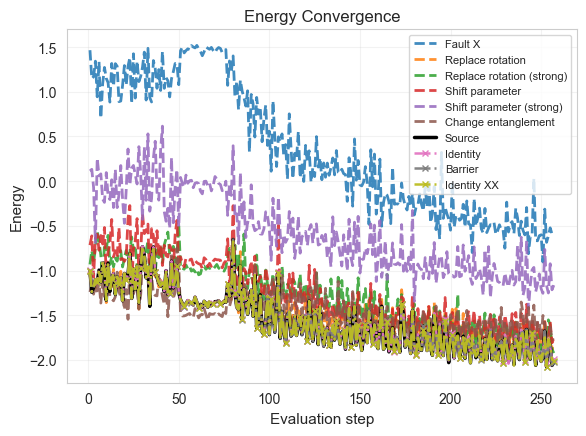

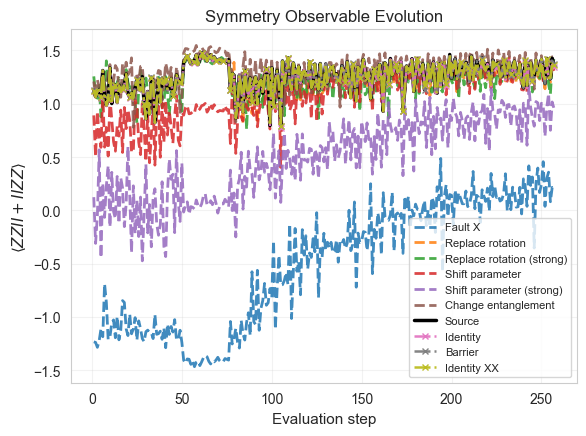

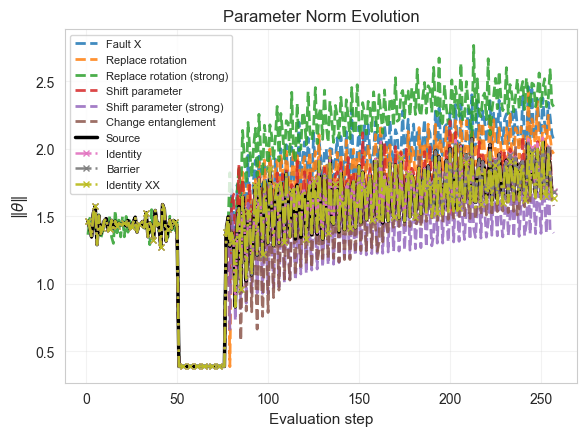

In [15]:
# Separate noisy figures

# (a) Energy
fig, ax = plt.subplots(figsize=(6, 4.5))

for name, follow_trace in fault_traces:
    ax.plot(
        follow_trace["eval"],
        follow_trace["energy"],
        label=pretty_relation_name(name),
        linestyle="--",
        linewidth=2,
        alpha=0.85,
    )

ax.plot(
    source_trace["eval"],
    source_trace["energy"],
    label="Source",
    color="black",
    linewidth=2.5,
)

for name, follow_trace in valid_traces:
    ax.plot(
        follow_trace["eval"],
        follow_trace["energy"],
        label=pretty_relation_name(name),
        linestyle="-.",
        linewidth=1.8,
        marker="x",
        markersize=4,
        markevery=4,
        alpha=0.95,
    )

ax.set_xlabel("Evaluation step")
ax.set_ylabel("Energy")
ax.set_title("Energy Convergence")
ax.grid(True, alpha=0.25)
ax.legend(loc="best", frameon=True, fontsize=8)

plt.tight_layout()
plt.savefig(figures_dir / "vqe_noisy_energy.pdf", bbox_inches="tight")
plt.savefig(figures_dir / "vqe_noisy_energy.png", dpi=300, bbox_inches="tight")
plt.show()


# (b) Symmetry
fig, ax = plt.subplots(figsize=(6, 4.5))

for name, follow_trace in fault_traces:
    ax.plot(
        follow_trace["eval"],
        follow_trace["symmetry"],
        label=pretty_relation_name(name),
        linestyle="--",
        linewidth=2,
        alpha=0.85,
    )

ax.plot(
    source_trace["eval"],
    source_trace["symmetry"],
    label="Source",
    color="black",
    linewidth=2.5,
)

for name, follow_trace in valid_traces:
    ax.plot(
        follow_trace["eval"],
        follow_trace["symmetry"],
        label=pretty_relation_name(name),
        linestyle="-.",
        linewidth=1.8,
        marker="x",
        markersize=4,
        markevery=4,
        alpha=0.95,
    )

ax.set_xlabel("Evaluation step")
ax.set_ylabel(r"$\langle ZZII + IIZZ \rangle$")
ax.set_title("Symmetry Observable Evolution")
ax.grid(True, alpha=0.25)
ax.legend(loc="best", frameon=True, fontsize=8)

plt.tight_layout()
plt.savefig(figures_dir / "vqe_noisy_symmetry.pdf", bbox_inches="tight")
plt.savefig(figures_dir / "vqe_noisy_symmetry.png", dpi=300, bbox_inches="tight")
plt.show()


# (c) Parameter norm
fig, ax = plt.subplots(figsize=(6, 4.5))

for name, follow_trace in fault_traces:
    ax.plot(
        follow_trace["eval"],
        follow_trace["param_norm"],
        label=pretty_relation_name(name),
        linestyle="--",
        linewidth=2,
        alpha=0.85,
    )

ax.plot(
    source_trace["eval"],
    source_trace["param_norm"],
    label="Source",
    color="black",
    linewidth=2.5,
)

for name, follow_trace in valid_traces:
    ax.plot(
        follow_trace["eval"],
        follow_trace["param_norm"],
        label=pretty_relation_name(name),
        linestyle="-.",
        linewidth=1.8,
        marker="x",
        markersize=4,
        markevery=4,
        alpha=0.95,
    )

ax.set_xlabel("Evaluation step")
ax.set_ylabel(r"$\|\theta\|$")
ax.set_title("Parameter Norm Evolution")
ax.grid(True, alpha=0.25)
ax.legend(loc="best", frameon=True, fontsize=8)

plt.tight_layout()
plt.savefig(figures_dir / "vqe_noisy_param.pdf", bbox_inches="tight")
plt.savefig(figures_dir / "vqe_noisy_param.png", dpi=300, bbox_inches="tight")
plt.show()

In [16]:
df_vqe_statevector = pd.read_csv(results_dir / "vqe_results_4q.csv")
df_vqe_statevector["phase"] = "statevector"

df_vqe_shot = pd.read_csv(results_dir / "vqe_results_4q_shot_based.csv")
df_vqe_shot["phase"] = "shot_based"

df_vqe_noisy = pd.read_csv(results_dir / "vqe_results_4q_noisy_shot_based.csv")
df_vqe_noisy["phase"] = "noisy_shot_based"

df_vqe_all_phases = pd.concat(
    [df_vqe_statevector, df_vqe_shot, df_vqe_noisy],
    ignore_index=True,
)

df_vqe_all_phases.to_csv(
    results_dir / "vqe_all_phases_4q.csv",
    index=False,
)

display(df_vqe_all_phases)

,relation,type,mean_delta_E,std_delta_E,mean_avg_energy_diff,mean_max_energy_diff,mean_sym_diff,mean_max_sym_diff,mean_param_diff,mean_max_param_diff,...,optimizer,oracle_variant,noise_model,energy_threshold,symmetry_threshold,param_threshold,one_qubit_error_rate,two_qubit_error_rate,readout_error_rate,include_thermal
0,identity,valid,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,barrier,valid,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,identity_xx,valid,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,fault_x,fault,0.228410,0.216641,0.554910,2.009532,0.395848,1.711397,3.067780,4.175201,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,fault_replace_rot,fault,0.068360,0.069643,0.105566,0.919561,0.078148,0.845041,1.085081,2.164741,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,fault_shift_param,fault,0.163269,0.152212,0.245844,1.091033,0.184149,0.970410,1.795452,2.960530,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,fault_change_entanglement,fault,0.281982,0.190702,0.260649,1.200008,0.161180,1.016901,2.829727,4.072373,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,fault_replace_rot_strong,fault,0.302711,0.236967,0.572032,1.654105,0.526516,1.548795,3.648947,4.977317,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,fault_shift_param_strong,fault,0.331737,0.262484,0.636484,1.820952,0.593471,1.787473,3.421922,4.790317,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,identity,valid,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,SPSA,deltaE_or_avgSym,none,0.05,0.01,inf,NaN,NaN,NaN,NaN


In [14]:
# THRESHOLD SENSITIVITY TEST for the 4 qubit noisy_shot experiment

df = pd.read_csv(results_dir / "vqe_run_level_results_4q_noisy_shot_based.csv")

if "phase" in df.columns:
    df = df[df["phase"] == "noisy_shot_based"].copy()

# Candidate thresholds centered around final values
ENERGY_VALUES = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]
SYMMETRY_VALUES = [0.02, 0.05, 0.08, 0.10, 0.12, 0.15, 0.20]

tuning_results = []

for e_th in ENERGY_VALUES:
    for s_th in SYMMETRY_VALUES:

        # Match the actual active noisy oracle
        predicted_violation = (
            (df["delta_E"] > e_th) |
            (df["avg_sym_diff"] > s_th)
        )

        valid_mask = df["type"] == "valid"
        fault_mask = df["type"] == "fault"

        fp_rate = predicted_violation[valid_mask].mean() * 100
        tp_rate = predicted_violation[fault_mask].mean() * 100

        tp = int(predicted_violation[fault_mask].sum())
        fn = int((~predicted_violation[fault_mask]).sum())
        fp = int(predicted_violation[valid_mask].sum())
        tn = int((~predicted_violation[valid_mask]).sum())

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = (
            2 * precision * recall / (precision + recall)
            if (precision + recall) > 0 else 0.0
        )

        tuning_results.append({
            "energy_threshold": e_th,
            "symmetry_threshold": s_th,
            "fp_rate_pct": round(fp_rate, 2),
            "tp_rate_pct": round(tp_rate, 2),
            "precision": round(precision, 4),
            "recall": round(recall, 4),
            "f1_score": round(f1, 4),
            "tp": tp,
            "fp": fp,
            "tn": tn,
            "fn": fn,
        })

df_tuning = pd.DataFrame(tuning_results)

# Favor zero false positives first, then highest F1 / TP rate
df_best = df_tuning[df_tuning["fp_rate_pct"] == 0].sort_values(
    by=["f1_score", "tp_rate_pct"],
    ascending=[False, False]
)

display(df_best.head(20))

df_tuning.to_csv(
    results_dir / "vqe_threshold_sensitivity_4q_noisy_shot_based.csv",
    index=False
)

,energy_threshold,symmetry_threshold,fp_rate_pct,tp_rate_pct,precision,recall,f1_score,tp,fp,tn,fn
8,0.10,0.05,0.0,80.00,1.0,0.8000,0.8889,48,0,30,12
15,0.15,0.05,0.0,75.00,1.0,0.7500,0.8571,45,0,30,15
22,0.20,0.05,0.0,71.67,1.0,0.7167,0.8350,43,0,30,17
29,0.25,0.05,0.0,71.67,1.0,0.7167,0.8350,43,0,30,17
36,0.30,0.05,0.0,71.67,1.0,0.7167,0.8350,43,0,30,17
43,0.35,0.05,0.0,71.67,1.0,0.7167,0.8350,43,0,30,17
50,0.40,0.05,0.0,71.67,1.0,0.7167,0.8350,43,0,30,17
9,0.10,0.08,0.0,70.00,1.0,0.7000,0.8235,42,0,30,18
16,0.15,0.08,0.0,65.00,1.0,0.6500,0.7879,39,0,30,21
10,0.10,0.10,0.0,63.33,1.0,0.6333,0.7755,38,0,30,22


In [17]:
def summarize_binary_performance(df):
    tp = int(((df["type"] == "fault") & (df["violation"])).sum())
    fn = int(((df["type"] == "fault") & (~df["violation"])).sum())
    fp = int(((df["type"] == "valid") & (df["violation"])).sum())
    tn = int(((df["type"] == "valid") & (~df["violation"])).sum())

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) else 0.0
    )

    false_positive_rate = 100 * fp / (fp + tn) if (fp + tn) else 0.0
    true_positive_rate = 100 * tp / (tp + fn) if (tp + fn) else 0.0

    return {
        "false_positive_rate": round(false_positive_rate, 2),
        "true_positive_rate": round(true_positive_rate, 2),
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "f1_score": round(f1, 4),
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn,
    }


def summarize_by_oracle(df_runs):
    rows = []

    for oracle_name, g in df_runs.groupby("oracle_variant"):
        stats = summarize_binary_performance(g)
        rows.append({
            "oracle_variant": oracle_name,
            **stats,
        })

    return pd.DataFrame(rows).sort_values(
        ["false_positive_rate", "f1_score", "true_positive_rate"],
        ascending=[True, False, False]
    ).reset_index(drop=True)


def summarize_by_oracle_and_relation(df_runs):
    rows = []

    for (oracle_name, relation_name, relation_type), g in df_runs.groupby(
        ["oracle_variant", "relation", "type"]
    ):
        row = {
            "oracle_variant": oracle_name,
            "relation": relation_name,
            "type": relation_type,
            "num_runs": len(g),
            "detection_rate": round(100 * g["violation"].mean(), 2),
            "mean_delta_E": round(g["delta_E"].mean(), 6),
        }

        if "avg_sym_diff" in g.columns and g["avg_sym_diff"].notna().any():
            row["mean_avg_sym_diff"] = round(g["avg_sym_diff"].mean(), 6)

        rows.append(row)

    return pd.DataFrame(rows).sort_values(
        ["oracle_variant", "type", "relation"]
    ).reset_index(drop=True)

In [18]:
# NOISY ORACLE ABLATION FROM EXISTING RUN-LEVEL RESULTS

df_noisy_compare = df_vqe_noisy_runs.copy()

# Oracle A: energy only
df_energy_only = df_noisy_compare.copy()
df_energy_only["oracle_variant"] = "energy_only"
df_energy_only["violation"] = df_energy_only["delta_E"] > ENERGY_THRESHOLD

# Oracle B: energy + symmetry
df_energy_sym = df_noisy_compare.copy()
df_energy_sym["oracle_variant"] = "energy_plus_symmetry"
df_energy_sym["violation"] = (
    (df_energy_sym["delta_E"] > ENERGY_THRESHOLD) |
    (df_energy_sym["avg_sym_diff"] > SYMMETRY_THRESHOLD)
)

df_noisy_ablation_runs = pd.concat(
    [df_energy_only, df_energy_sym],
    ignore_index=True
)

print("Noisy oracle-level summary:")
display(summarize_by_oracle(df_noisy_ablation_runs))

print("Noisy oracle-by-relation summary:")
display(summarize_by_oracle_and_relation(df_noisy_ablation_runs))

df_noisy_ablation_runs.to_csv(
    results_dir / "vqe_noisy_oracle_ablation_runs.csv",
    index=False,
)

Noisy oracle-level summary:


,oracle_variant,false_positive_rate,true_positive_rate,precision,recall,f1_score,tp,fp,tn,fn
0,energy_plus_symmetry,0.0,80.00,1.0,0.8000,0.8889,48,0,30,12
1,energy_only,0.0,56.67,1.0,0.5667,0.7234,34,0,30,26


Noisy oracle-by-relation summary:


,oracle_variant,relation,type,num_runs,detection_rate,mean_delta_E,mean_avg_sym_diff
0,energy_only,fault_change_entanglement,fault,10,40.0,0.091309,0.114122
1,energy_only,fault_replace_rot,fault,10,10.0,0.058643,0.035147
2,energy_only,fault_replace_rot_strong,fault,10,90.0,0.478076,0.393606
3,energy_only,fault_shift_param,fault,10,50.0,0.120752,0.064178
4,energy_only,fault_shift_param_strong,fault,10,80.0,0.375342,0.273887
5,energy_only,fault_x,fault,10,70.0,0.463232,0.619696
6,energy_only,barrier,valid,10,0.0,0.000000,0.000000
7,energy_only,identity,valid,10,0.0,0.019678,0.014443
8,energy_only,identity_xx,valid,10,0.0,0.011328,0.009217
9,energy_plus_symmetry,fault_change_entanglement,fault,10,100.0,0.091309,0.114122
